# Jigsaw Toxic Comment Dataset: Preliminary Exploration
This notebook analyzes the **Jigsaw Toxic Comment** [dataset](https://www.kaggle.com/competitions/jigsaw-toxic-comment-classification-challenge/data) to identify which data subsets and features are essential for the model. This data will be used for **initial fine-tuning** to provide the model with a foundational understanding of toxicity patterns before further specialization.

## Importing Dependencies

In [1]:
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from toxicity_detector.utils.plotting import *

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", None)

## Loading Data

In [ ]:
from toxicity_detector.config import JIGSAW_TOXIC_RAW

In [ ]:
train_df = pd.read_csv(JIGSAW_TOXIC_RAW["train"])
test_df = pd.read_csv(JIGSAW_TOXIC_RAW["test"])
test_labels_df = pd.read_csv(JIGSAW_TOXIC_RAW["test_labels"])

## Data Exploration

In [4]:
train_df.shape, test_df.shape, test_labels_df.shape

((159571, 8), (153164, 2), (153164, 7))

In [5]:
train_df.isnull().sum().any(), test_df.isnull().sum().any(), test_labels_df.isnull().sum().any()

(np.False_, np.False_, np.False_)

In [6]:
# Count of toxic comments in both datasets
train_df[train_df["toxic"] == 1].shape[0], test_labels_df[test_labels_df["toxic"] == 1].shape[0]

(15294, 6090)

In [7]:
# Count of comments which are not toxic but have other labels
train_df[(train_df["toxic"] == 0) & (train_df.iloc[:, 3:].sum(axis=1) > 0)].shape[0], test_labels_df[(test_labels_df["toxic"] == 0) & (test_labels_df.iloc[:, 3:].sum(axis=1) > 0)].shape[0]

(931, 153)

In [8]:
cols = train_df.columns.to_list()
cols

['id',
 'comment_text',
 'toxic',
 'severe_toxic',
 'obscene',
 'threat',
 'insult',
 'identity_hate']

In [9]:
# List of comment categories
categories = cols[2:]
categories

['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

### Cleaning the Jigsaw test set and merging it with the training data

In [10]:
# Remove rows with all -1 labels (i.e., no labels) in the test set
test_labels_df = test_labels_df[(test_labels_df[categories] != -1).all(axis=1)]
test_labels_df.shape

(63978, 7)

In [11]:
# Combine test data with labels
test_df = test_df.merge(test_labels_df, on="id", how="inner")
test_df.shape

(63978, 8)

In [12]:
df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
df.shape

(223549, 8)

In [13]:
# Count of labels per comment
df["label_count"] = df[categories].sum(axis=1)
df[df["label_count"] != 0]["label_count"].value_counts().sort_index()

label_count
1    8202
2    5010
3    6290
4    2371
5     550
6      45
Name: count, dtype: int64

In [14]:
co_occurrence_matrix = df[categories].T.dot(df[categories])
co_occurrence_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,21384,1962,11552,654,10686,1995
severe_toxic,1962,1962,1880,158,1701,448
obscene,11552,1880,12140,439,8884,1570
threat,654,158,439,689,445,145
insult,10686,1701,8884,445,11304,1762
identity_hate,1995,448,1570,145,1762,2117


In [15]:
# Analyzing how often each category co-occurs with only "toxic" label
co_occurrence = pd.Series(dtype=int, index=categories)

for col in categories:
    co_occurrence[col] = df[(df[col] == 1) & (df["toxic"] == 1) & (df["label_count"] == 2)].shape[0]
    
co_occurrence

toxic            4773.0
severe_toxic       41.0
obscene          2612.0
threat            163.0
insult           1754.0
identity_hate     203.0
dtype: float64

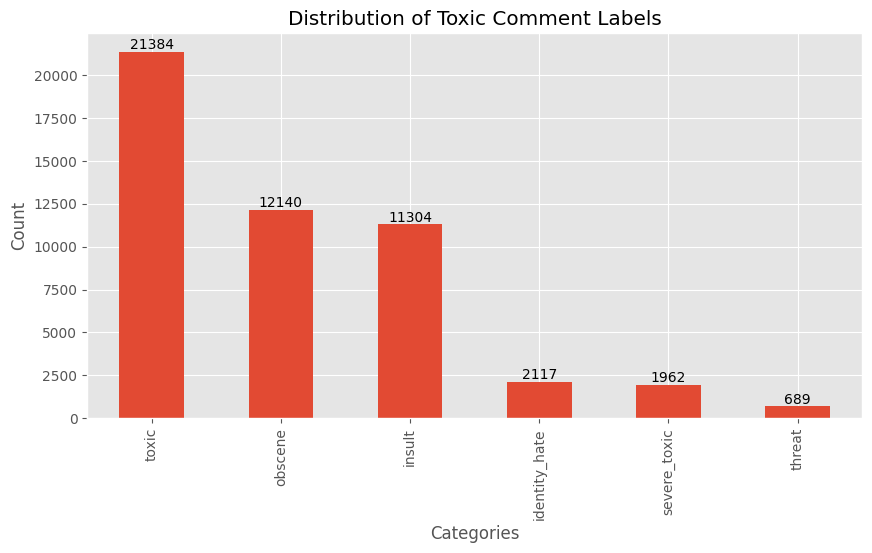

In [16]:
plot_category_distribution(df, categories, title="Distribution of Toxic Comment Labels", figsize=(10, 5))

In [17]:
df[categories].corr()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,1.000000,0.289325,0.697349,0.161360,0.666690,0.281483
severe_toxic,0.289325,1.000000,0.375318,0.131472,0.350608,0.212644
obscene,0.697349,0.375318,1.000000,0.143005,0.745039,0.296548
threat,0.161360,0.131472,0.143005,1.000000,0.151066,0.115382
insult,0.666690,0.350608,0.745039,0.151066,1.000000,0.348853
identity_hate,0.281483,0.212644,0.296548,0.115382,0.348853,1.000000


In [18]:
df["comment_length"] = df["comment_text"].str.split().apply(len)
df[["comment_length", "toxic"]].groupby("toxic").describe()

comment_length                                                      
               count       mean         std  min   25%   50%   75%     max
toxic                                                                     
0           202165.0  68.415161   98.633811  1.0  17.0  37.0  77.0  1990.0
1            21384.0  48.573466  105.424224  1.0  10.0  21.0  45.0  2321.0

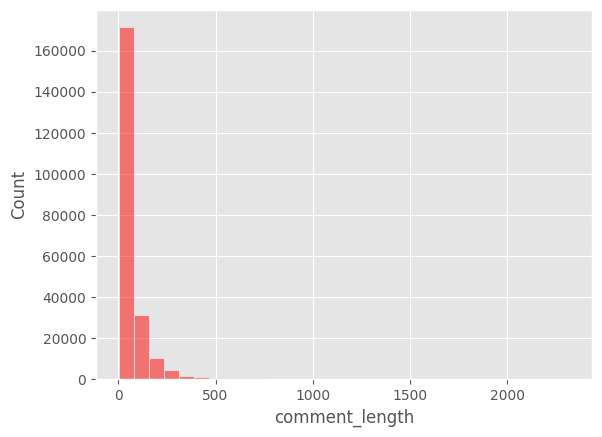

In [19]:
sns.histplot(df["comment_length"],  bins=30, color="red", label="Toxic", alpha=0.5, fill=True)
plt.show()

In [20]:
for col in categories:
    print(f"Number of comments in only {col} category: {df[(df[col] == 1) & (df[categories].sum(axis=1) == 1)].shape[0]}")

Number of comments in only toxic category: 7376
Number of comments in only severe_toxic category: 0
Number of comments in only obscene category: 366
Number of comments in only threat category: 27
Number of comments in only insult category: 365
Number of comments in only identity_hate category: 68


In [21]:
for col in categories:
    if col != "toxic":
        print(f"Number of comments in only {col} and toxic category: {df[(df[col] == 1) & (df['toxic'] == 1) & (df[categories].sum(axis=1) == 2)].shape[0]}")

Number of comments in only severe_toxic and toxic category: 41
Number of comments in only obscene and toxic category: 2612
Number of comments in only threat and toxic category: 163
Number of comments in only insult and toxic category: 1754
Number of comments in only identity_hate and toxic category: 203


In [ ]:
# Save combined dataframe to a csv file
df.to_csv(JIGSAW_TOXIC_RAW["combined"], index=False)